In [1]:
# Alex Medina
# AST5765
# Practicum 6
# October 2025

In [3]:
##### IMPORTS

import os
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as fits
from hw8_amedina import *

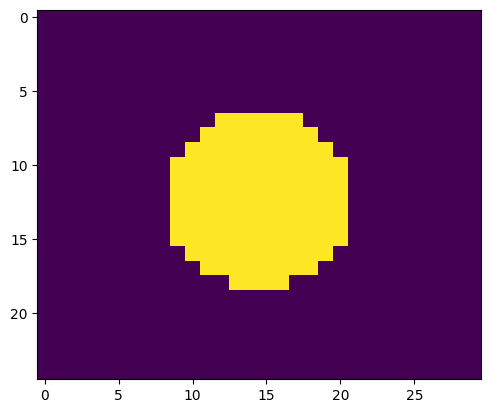

In [ ]:
## PRACTICUM

def disk(radius, center, shape):
    y, x = np.ogrid[:shape[0], : shape[1]]
    mask = (( y - center[0])**2 + (x - center[1])**2 ) < radius**2
    return mask

new_disk = disk(6.2, (12.3, 14.5), (25, 30))

plt.imshow(new_disk)

#disktest = fits.writeto('disktest.fits', new_disk)

In [6]:
# k_lampon, k_lampoff
# Build up to median combining files

# Selecting file names
lamponfile = []
lampoffile = []

for filename in os.listdir(datadir):
    if filename.startswith('k_lampon'):
        file = filename.split(fext)[0]
        lamponfile.append(file)
    elif filename.startswith('k_lampoff'):
        file = filename.split(fext)[0]
        lampoffile.append(file)

lamponfile, lampoffile = sorted(lamponfile), sorted(lampoffile)

# Choosing a random indice from the list
randf  = lamponfile[int(np.random.uniform(0, len(lamponfile)))]
file   = fits.getdata(datadir + randf + fext)
nx, ny = file.shape

non, noff = len(lamponfile), len(lampoffile)

# DATACUBES
onarr  = np.zeros( (non, ny, nx))
offarr = np.zeros( (noff, ny, nx))

for i in range(non):
    onarr[i, :, :] = fits.getdata(datadir + lamponfile[i] + fext)
    
for i in range(noff):
    offarr[i, :, :] = fits.getdata(datadir + lampoffile[i] + fext)

# Median combining the files
onmed  = np.median(onarr, axis=0)
offmed = np.median(offarr, axis=0)

In [7]:
# SAVING FLAT

flat = onmed - offmed

normval = np.median( flat[ norm_region[0][0] : norm_region[1][0],
                    norm_region[0][1] : norm_region[1][1] ])

flat /= normval

print(flat[217, 184])

1.0249318083935492


In [9]:
# SAVING

fits.writeto('flat.fits', flat, overwrite=True)

flat = np.where( flat ==0., 1, flat)

# Sub the flat from all the sky subtracted arr

obj_ssflat = objarr / flat

# printing each frame [217, 184] index
# print(f'Index [217, 184] of each frame is: {obj_ssflat[:, 217, 184]}')
for i in range(len(objarr)):
    print(i, obj_ssflat[i, 217, 184])

0 -117.27832924293632
1 39.55794339054814
2 10.673034139455607
3 149.08506856351434
4 65.96485850657102
5 -52.324326921731995
6 0.0
7 -110.24486736411063
8 -95.25303224654466


In [10]:
# Write the last resulting frame
fits.writeto('stars_13s_9_flat.fits', obj_ssflat[-1, :, :], overwrite=True)